# 03bis LightGBM Deep Momentum Network (V2)

22 features (momentum + region + CPD, each with a lag-1 twin) -> LightGBM (L2) -> `sigmoid(alpha* x score)` -> EMA (halflife=10d) -> CPD risk filter -> `positions_v2.parquet` -> NB04.

Walk-forward: 16 annual folds 2011-2026, expanding windows since 2006.

This replaces the previous LightGBM implementation (which trained the same way as the LSTM: vol-target-scaled positions, 3 static 5-year folds). V2 instead uses raw `sigmoid(alpha * score)` positions with no vol-target rescaling, and re-trains annually on an expanding window design.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.lgbm import (
    load_panel, load_cpd_features, build_feature_matrix, input_summary,
    build_feature_cols, TARGET_COL,
    walk_forward_splits, run_walk_forward, train_fold_lgb, compute_shap,
    smooth_positions, apply_cpd_filter, save_outputs,
)

with open(PROJECT_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

In [2]:
lcfg = cfg["lgbm"]
CPD_LBW = cfg["dmn"]["cpd_lbw"]
CPD_STRIDE = cfg["dmn"].get("cpd_stride", 1)
SEED = cfg["dmn"].get("seed", 42)

print(f"LightGBM : {lcfg['n_estimators']} trees | max_depth={lcfg['max_depth']} "
      f"| num_leaves={lcfg['num_leaves']}")
print(f"Position : EMA halflife={lcfg['position_halflife']}d | alpha in [1, {lcfg['alpha_max']}]")
print(f"Protocol : {'expanding' if lcfg['window_years'] is None else str(lcfg['window_years']) + 'y rolling'} "
      f"window, test years >= {lcfg['test_start']}")
print(f"CPD      : GP-based, lbw={CPD_LBW}, stride={CPD_STRIDE}")

LightGBM : 300 trees | max_depth=4 | num_leaves=15
Position : EMA halflife=10d | alpha in [1, 200]
Protocol : expanding window, test years >= 2011
CPD      : GP-based, lbw=21, stride=1


## 1. Data

Panel from NB01 (returns + momentum + region) merged with GP-based CPD scores (severity `nu`, location `gamma`) from NB02, at lookback window `cpd_lbw`. Target: `next_return` (J+1). Both the panel and the CPD features are cached to parquet after the first build.

In [3]:
panel = load_panel(cfg, PROJECT_ROOT)
cpd_features = load_cpd_features(cfg, PROJECT_ROOT, CPD_LBW, CPD_STRIDE)

feat = build_feature_matrix(panel, cpd_features, CPD_LBW)
feature_cols = build_feature_cols(CPD_LBW)

display(input_summary(feat, CPD_LBW))

,item,value
0,rows,"2,802,379"
1,tickers,"1,311"
2,date range,2006-02-01 -> 2026-05-05
3,features,22
4,model,LightGBM L2 + calibration alpha* Sharpe-net (V2)
5,target,next_return


## 2. Features -- 22 signals

| Group | N | |
|---|---|---|
| Momentum | 18 | `norm_ret` x5, `macd` x3 pairs, `ewma_vol` -- current + lag-1 |
| Region | 2 | `region_rel_1d` -- over/under-performance vs region -- current + lag-1 |
| CPD (stock) | 2 | `cpd_nu_{lbw}_lag1` (severity) + `cpd_gamma_{lbw}_lag1` (location) -- GP changepoint kernel (Wood, Roberts & Zohren 2022) |

> The lag-1 twins give LightGBM temporal dynamics without needing sequences (no LSTM).

> Note: this substitutes the project's existing GP-based CPD features (single method, per lookback window) for the stock-level CUSUM + BOCPD severity scores used in the original V2 design -- same feature count and role (severity + location), different underlying method, since only the GP-based CPD pipeline is precomputed in this project.

## 3. Architecture

LightGBM L2/MSE, 300 trees, depth 4, L1+L2 -- suited to a weak daily-return signal.

**alpha\*** is calibrated on net Sharpe (25bps) via `sigmoid(alpha x score)`. Alpha≈1 -> near-flat positions | Alpha≈200 -> strongly amplified signal.

In [4]:
display(pd.DataFrame([
    {"param": "n_estimators",      "value": str(lcfg["n_estimators"]),      "role": "Number of trees"},
    {"param": "learning_rate",     "value": str(lcfg["learning_rate"]),     "role": "Shrinkage -- slow, stable convergence"},
    {"param": "max_depth",         "value": str(lcfg["max_depth"]),         "role": "Max depth -- shallow trees, limits memorisation"},
    {"param": "min_child_samples", "value": str(lcfg["min_child_samples"]), "role": "Min obs/leaf -- avoids splitting on outliers"},
    {"param": "reg_alpha (L1)",    "value": str(lcfg["reg_alpha"]),         "role": "L1 penalty -- pushes useless weights to 0"},
    {"param": "reg_lambda (L2)",   "value": str(lcfg["reg_lambda"]),        "role": "L2 penalty -- shrinks large coefficients"},
    {"param": "EMA halflife",      "value": f"{lcfg['position_halflife']} days", "role": "Temporal smoothing of positions -- turnover control"},
]))

,param,value,role
0,n_estimators,300,Number of trees
1,learning_rate,0.05,"Shrinkage -- slow, stable convergence"
2,max_depth,4,"Max depth -- shallow trees, limits memorisation"
3,min_child_samples,20,Min obs/leaf -- avoids splitting on outliers
4,reg_alpha (L1),0.1,L1 penalty -- pushes useless weights to 0
5,reg_lambda (L2),0.1,L2 penalty -- shrinks large coefficients
6,EMA halflife,10 days,Temporal smoothing of positions -- turnover co...


## 4. Walk-forward -- 2011-2026

16 annual folds, expanding windows since 2006. The final `val_frac` (10%) of each fold's training window calibrates alpha*.

In [5]:
splits = walk_forward_splits(feat, test_start=lcfg["test_start"], window_years=lcfg["window_years"])

fold_rows = []
for i, sp in enumerate(splits, start=1):
    train_start = sp["train_start"].year if sp.get("train_start") else 2006
    train_end = sp["train_end"].year
    fold_rows.append({
        "fold": i,
        "train": f"{train_start} -> {train_end}",
        "test": sp["test_year"],
        "n_train_rows": feat.loc[feat["date"] <= sp["train_end"]].shape[0],
    })

display(pd.DataFrame(fold_rows))

# trains one LightGBM model per fold, calibrates alpha* on validation, predicts on the test year
positions, fold_metrics = run_walk_forward(feat, feature_cols=feature_cols, cfg=cfg, seed=SEED, verbose=False)

fold_display = fold_metrics[["test_year", "val_ic", "alpha_calibrated", "val_sharpe"]].copy()
fold_display = fold_display.rename(columns={
    "test_year": "test year",
    "val_ic": "IC (val)",
    "alpha_calibrated": "alpha* calibrated",
    "val_sharpe": "Sharpe gross (val)",
})
fold_display["alpha* calibrated"] = fold_display["alpha* calibrated"].astype(int)
fold_display["IC (val)"] = fold_display["IC (val)"].map("{:.4f}".format)
fold_display["Sharpe gross (val)"] = fold_display["Sharpe gross (val)"].map("{:+.3f}".format)

print("Results by fold")
display(fold_display)

,fold,train,test,n_train_rows
0,1,2006 -> 2010,2011,669975
1,2,2006 -> 2011,2012,811121
2,3,2006 -> 2012,2013,950003
3,4,2006 -> 2013,2014,1088214
4,5,2006 -> 2014,2015,1226684
5,6,2006 -> 2015,2016,1365805
6,7,2006 -> 2016,2017,1505873
7,8,2006 -> 2017,2018,1642545
8,9,2006 -> 2018,2019,1778963
9,10,2006 -> 2019,2020,1916509


Results by fold


,test year,IC (val),alpha* calibrated,Sharpe gross (val)
0,2011,0.0250,46,+0.889
1,2012,0.0619,46,-0.558
2,2013,0.0311,1,+0.533
3,2014,0.0420,200,+0.373
4,2015,0.0047,1,+0.041
5,2016,0.0413,1,+0.248
6,2017,0.0236,1,+0.149
7,2018,0.0337,1,+0.630
8,2019,0.0229,115,-0.306
9,2020,0.0178,1,+0.153


## 5. Positions

1. **EMA** (halflife=10d) -- smooths positions, cuts turnover
2. **CPD filter** -- pulls toward 0.5 when a regime break is detected

`pos_filtered = 0.5 + (1 - strength * nu) * (pos - 0.5)`

In [6]:
positions_smooth = smooth_positions(positions, halflife=lcfg["position_halflife"])
positions_filtered = apply_cpd_filter(positions_smooth, feat, cpd_lbw=CPD_LBW, strength=lcfg["cpd_filter_strength"])

check = positions_smooth.merge(
    positions_filtered.rename(columns={"position": "pos_filtered"}),
    on=["date", "ticker"], how="inner",
)
frac_affected = ((check["pos_filtered"] - check["position"]).abs() > 0.01).mean()

print("Position smoothing and CPD filter")
print("Raw sigmoid std :", f"{positions['position'].std():.4f}")
print("After EMA std   :", f"{positions_smooth['position'].std():.4f}")
print("After CPD filter:", f"{frac_affected:.1%}", "positions adjusted")

Position smoothing and CPD filter
Raw sigmoid std : 0.0187
After EMA std   : 0.0082
After CPD filter: 7.6% positions adjusted


## 6. Out-of-sample performance

Equal-weighted portfolio, positions after EMA + CPD, returns **gross of transaction costs** -- the full net-of-cost analysis (with the vol-target framework and the LSTM variants) lives in NB04.

Out-of-sample performance, equal-weighted and gross of TC
Annualised return: 3.09%
Annualised vol   : 8.44%
Sharpe ratio     : +0.367
Max drawdown     : -20.74%
Hit rate         : 51.2%
Trading days     : 3,863


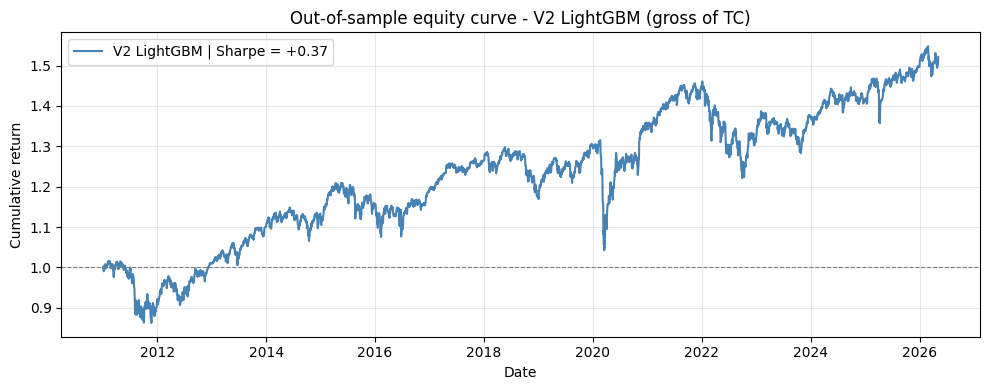

In [7]:
import matplotlib.pyplot as plt

# equal-weighted portfolio return = position x next-day return, averaged across stocks each day
eval_df = positions_filtered.merge(
    feat[["date", "ticker", TARGET_COL]],
    on=["date", "ticker"], how="inner",
)
eval_df["strat_ret"] = eval_df["position"] * eval_df[TARGET_COL]

daily_ret = eval_df.groupby("date")["strat_ret"].mean().sort_index()
cum_ret = (1 + daily_ret).cumprod()

ann_ret = daily_ret.mean() * 252
ann_vol = daily_ret.std() * np.sqrt(252)
sharpe = ann_ret / ann_vol if ann_vol > 0 else float("nan")
max_dd = (cum_ret / cum_ret.cummax() - 1).min()
hit_rate = (eval_df["strat_ret"] > 0).mean()

print("Out-of-sample performance, equal-weighted and gross of TC")
print("Annualised return:", f"{ann_ret:.2%}")
print("Annualised vol   :", f"{ann_vol:.2%}")
print("Sharpe ratio     :", f"{sharpe:+.3f}")
print("Max drawdown     :", f"{max_dd:.2%}")
print("Hit rate         :", f"{hit_rate:.1%}")
print("Trading days     :", f"{daily_ret.shape[0]:,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum_ret.index, cum_ret.values, color="steelblue", linewidth=1.5,
        label=f"V2 LightGBM | Sharpe = {sharpe:+.2f}")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.set_title("Out-of-sample equity curve - V2 LightGBM (gross of TC)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Annual Sharpe -- V1 LSTM vs V2 LightGBM (common period 2011-2025)

,year,V2 LightGBM,V1 LSTM
0,2011,-0.6370,-0.8280
1,2012,1.1480,1.3190
2,2013,1.4790,1.8800
3,2014,0.4820,-0.0080
4,2015,0.2500,0.7850
5,2016,0.4080,0.2170
6,2017,1.4510,2.8860
7,2018,-1.0530,-0.9130
8,2019,1.6320,1.3780
9,2020,0.3030,-1.5560


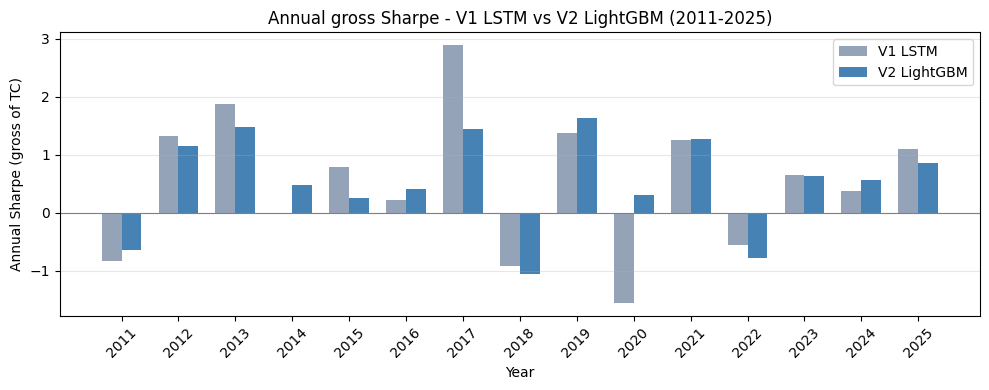

In [8]:
import matplotlib.pyplot as plt
import numpy as np


# per-year Sharpe ratio of a daily-return column, used to compare V1 and V2 year by year
def annual_sharpe_table(data, ret_col, label):
    tmp = data.copy()
    tmp["year"] = pd.to_datetime(tmp["date"]).dt.year

    rows = []
    for year, grp in tmp.groupby("year"):
        daily = grp.groupby("date")[ret_col].mean()
        ann_ret_y = daily.mean() * 252
        ann_vol_y = daily.std() * np.sqrt(252)
        sharpe_y = ann_ret_y / ann_vol_y if ann_vol_y > 0 else float("nan")
        rows.append({"year": year, label: round(sharpe_y, 3)})
    return pd.DataFrame(rows)


v2_df = annual_sharpe_table(eval_df, "strat_ret", "V2 LightGBM")

# load V1 LSTM's saved test-fold predictions (scripts/03bis_walk_forward.py) for comparison
V1_SUFFIX = "expanding_cpd21_s5_longonly_tc25bps"
models_dir = PROJECT_ROOT / cfg["data"]["processed_mod"]
v1_all = []

for i in range(len(cfg[f"folds_{cfg['fold_type']}"])):
    path = models_dir / f"predictions_fold{i}_{V1_SUFFIX}.csv"
    if path.exists():
        v1_all.append(pd.read_csv(path, parse_dates=["date"]))

if v1_all:
    v1_full = pd.concat(v1_all, ignore_index=True)
    v1_df = annual_sharpe_table(v1_full, "strat_ret", "V1 LSTM")
    cmp = v2_df.merge(v1_df, on="year", how="inner").sort_values("year")
else:
    cmp = v2_df.copy()
    cmp["V1 LSTM"] = float("nan")
    print("V1 predictions not found -- run scripts/03bis_walk_forward.py first.")

cmp = cmp[cmp["year"].between(2011, 2025)].reset_index(drop=True)
display(cmp)

years = cmp["year"].astype(str).tolist()
x = np.arange(len(years))
width = 0.35
has_v1 = cmp["V1 LSTM"].notna().any()

fig, ax = plt.subplots(figsize=(10, 4))
if has_v1:
    ax.bar(x - width / 2, cmp["V1 LSTM"].fillna(0), width, label="V1 LSTM", color="#94a3b8")
    ax.bar(x + width / 2, cmp["V2 LightGBM"], width, label="V2 LightGBM", color="steelblue")
else:
    ax.bar(x, cmp["V2 LightGBM"], width, label="V2 LightGBM", color="steelblue")

ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Sharpe (gross of TC)")
ax.set_title("Annual gross Sharpe - V1 LSTM vs V2 LightGBM (2011-2025)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 7. Interpretability -- SHAP

Model retrained on the full panel to stabilise SHAP values.

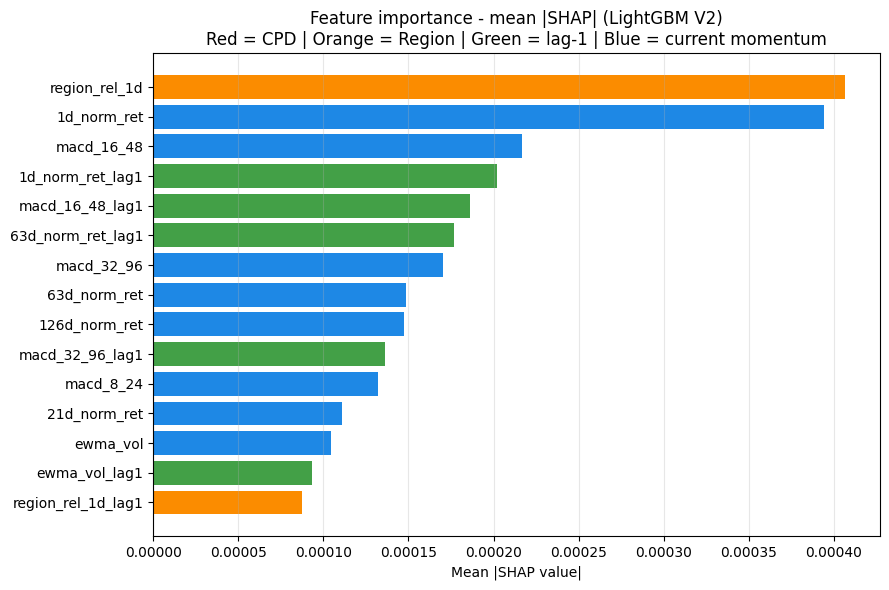

In [9]:
import matplotlib.pyplot as plt

# retrain once on the full panel (more stable SHAP values than a single fold's model)
lgb_params = {
    "learning_rate": lcfg["learning_rate"], "max_depth": lcfg["max_depth"],
    "num_leaves": lcfg["num_leaves"], "min_child_samples": lcfg["min_child_samples"],
    "subsample": lcfg["subsample"], "subsample_freq": 1,
    "colsample_bytree": lcfg["colsample_bytree"],
    "reg_alpha": lcfg["reg_alpha"], "reg_lambda": lcfg["reg_lambda"],
    "n_jobs": -1, "verbose": -1,
}

X_all_df = feat.dropna(subset=feature_cols + [TARGET_COL])
X_all = X_all_df[feature_cols].fillna(0.0).to_numpy(dtype=np.float64)
y_all = X_all_df[TARGET_COL].to_numpy(dtype=np.float64)

n_val = max(1_000, int(len(X_all) * lcfg["val_frac"]))
model_shap, _, _ = train_fold_lgb(
    X_all[:-n_val], y_all[:-n_val], X_all[-n_val:], y_all[-n_val:],
    lgb_params=lgb_params, n_estimators=lcfg["n_estimators"], seed=SEED,
    alpha_max=lcfg["alpha_max"], position_halflife=lcfg["position_halflife"],
    transaction_cost=lcfg["transaction_cost"],
)

shap_df = compute_shap(model_shap, feat, feature_cols, seed=SEED)
top = shap_df.head(15).sort_values("mean_abs_shap", ascending=True)


# color-codes each feature by category for the chart below
def shap_color(feature):
    if "nu_" in feature or "gamma_" in feature:
        return "#E53935"
    if "region_rel" in feature:
        return "#FB8C00"
    if "_lag1" in feature:
        return "#43A047"
    return "#1E88E5"


colors = [shap_color(feature) for feature in top["feature"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["mean_abs_shap"], color=colors)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(
    "Feature importance - mean |SHAP| (LightGBM V2)\n"
    "Red = CPD | Orange = Region | Green = lag-1 | Blue = current momentum"
)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 8. Export

-> `positions_v2.parquet` + `fold_metrics_v2.parquet` in `data/processed/stoxx600/` -> NB04.

## 9. Limitations

- Daily stock returns are a weak, noisy signal -- the model is only marginally better than a coin flip on any given day.
- CPD contribution is expected to be marginal on top of the momentum/region features, consistent with the LSTM+CPD findings elsewhere in this project.
- No vol-target scaling is applied here (unlike the LSTM pipeline) -- positions are the raw calibrated `sigmoid(alpha * score)`. NB04 handles the vol-target-consistent comparison against the other strategies.

In [10]:
display(save_outputs(cfg, PROJECT_ROOT, positions_filtered, fold_metrics))

,output,rows,path
0,positions,"2,132,404",data/processed/stoxx600/positions_v2.parquet
1,fold_metrics,16,data/processed/stoxx600/fold_metrics_v2.parquet
